# WFI2033 data_visullization

读取 WFI2033 HMC 结果并可视化：
- Trace plot
- Corner plot
- Data / Model / Residual / Source（含 source-plane AGN trace 点）
- Base PSF 与 corrected PSF

In [1]:
import os
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

import arviz as az
import corner
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import numpyro
import xarray as xr
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
numpyro.enable_x64()

# Ensure local WFI2033 modules are importable
if str(Path.cwd()) not in sys.path:
    sys.path.append(str(Path.cwd()))

from herculens_import_main import (
    get_pixel_grid,
    trace_current_agn_to_source,
    params2kwargs_EPL_w_shear,
    params2kwargs_SIS,
    params2kwargs_multi_gauss_light,
)
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF
from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.PointSourceModel.point_source_model import PointSourceModel
from lens_images_extension import LensImageExtension, pixelize_plane as pixelize_plane_single
from herculens.Util import model_util


[CudaDevice(id=0)]


In [2]:
pix_scale = 0.031  # arcsec / pixel

DATA_DIR = Path("../../Data/WFI2033")
RAW_DATA_PATH = DATA_DIR / "jw01198-o004_t004_nircam_clear-f115w_i2d.fits"
MASK_PATH = DATA_DIR / "mask_out_center.fits"
MASK_OUT_PATH = DATA_DIR / "mask_out_center.fits"

products_dir = Path('./result/read_data/data_products')
NC_PATH = Path('/mnt/lustre/tianli/quasar_hmc/WFI2033_psf_correct_all.nc')
HMC_MEDIAN_PATH = Path('./result/read_data/HMC_median_draw.nc')

with fits.open(RAW_DATA_PATH, memmap=True) as hdul_raw:
    exposure_time = float(hdul_raw[0].header.get("EXPTIME", hdul_raw[0].header.get("TEXPTIME", 1.0)))

data = np.array(fits.getdata(products_dir / 'data_bkg_sub.fits'), dtype=float)
rms_file = np.array(fits.getdata(products_dir / 'rms_with_psf_extra.fits'), dtype=float)
psf_base = np.array(fits.getdata(products_dir / 'psf_base.fits'), dtype=float)
mask = np.array(fits.getdata(MASK_PATH), dtype=bool)
mask_out = np.array(fits.getdata(MASK_OUT_PATH), dtype=bool)
mask = mask_out.copy()

psf_base = np.clip(psf_base, 0.0, None)
psf_base = psf_base / np.sum(psf_base)

inf_data_pixel = az.from_netcdf(str(NC_PATH))
post = inf_data_pixel.posterior
HMC_median = xr.load_dataset(HMC_MEDIAN_PATH)
num_chains = int(post.sizes["chain"])

conj_points = jnp.array([
    [1.20212170716053, -0.12271885209256231],
    [0.9053233071260114, 0.5277189685977776],
    [-1.0461673774453952, 1.0081083299749878],
    [-0.1255456241215261, -0.8965524340129204],
])

G1_MASS_CENTER = (1.556, 1.299)
G2_MASS_CENTER = (2.145, -3.326)

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = get_pixel_grid(jnp.array(data), pix_scale)


In [3]:
# Build LensImage object (pixelated source) for forward model visualization
noise = Noise(nx, ny, exposure_time=exposure_time)
psf_obj = PSF(psf_type='PIXEL', kernel_point_source=psf_base)

mass_model_pixel = MassModel(['EPL', 'SHEAR', 'SIS', 'SIS'])
lens_light_model_pixel = LightModel(['MULTI_GAUSSIAN_ELLIPSE'], {})

pixel_grid_shape = int(post['pixels_source_grid'].shape[-1])

source_light_model_pixel = LightModel(
    ['PIXELATED'],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape},
)

point_source_model_pixel = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model_pixel,
    image_plane=pixel_grid,
)

lens_image_pixel = LensImageExtension(
    pixel_grid,
    psf_obj,
    noise_class=noise,
    lens_light_model_class=lens_light_model_pixel,
    lens_mass_model_class=mass_model_pixel,
    source_model_class=source_light_model_pixel,
    point_source_model_class=point_source_model_pixel,
    source_arc_mask=jnp.array(mask),
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': 1},
    source_grid_scale=1,
)


In [4]:
model_image_med = np.array(HMC_median['model_image'].values)
psf_corr_med = np.array(HMC_median['psf_kernel_corrected'].values)
psf_corr_med = np.clip(psf_corr_med, 0.0, None)
psf_corr_med = psf_corr_med / np.sum(psf_corr_med, axis=(1, 2), keepdims=True)


def _chain_param_dict(i: int):
    keys = [
        'theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1',
        'theta_E_g1', 'theta_E_g2',
        'amp_lens', 'sigma_lens', 'e_lens', 'center_lens',
        'pixels_source_grid', 'ra_ps', 'dec_ps', 'log10_amp_ps',
    ]
    p = {k: np.array(HMC_median[k].isel(chain=i).values) for k in keys}

    # SIS fixed centers are deterministic in model; inject explicitly for params2kwargs_SIS
    p['center_1_g1'] = np.array([G1_MASS_CENTER[0]], dtype=float)
    p['center_2_g1'] = np.array([G1_MASS_CENTER[1]], dtype=float)
    p['center_1_g2'] = np.array([G2_MASS_CENTER[0]], dtype=float)
    p['center_2_g2'] = np.array([G2_MASS_CENTER[1]], dtype=float)
    return p


def params_2_kwargs(params: dict):
    kwargs_lens = (
        params2kwargs_EPL_w_shear(params, '1')
        + params2kwargs_SIS(params, 'g1')
        + params2kwargs_SIS(params, 'g2')
    )

    return {
        'kwargs_lens': kwargs_lens,
        'kwargs_lens_light': params2kwargs_multi_gauss_light(params, 'lens'),
        'kwargs_source': [{'pixels': np.asarray(params['pixels_source_grid'])}],
        'kwargs_point_source': [{
            'ra': np.asarray(params['ra_ps']),
            'dec': np.asarray(params['dec_ps']),
            'amp': np.power(10.0, np.asarray(params['log10_amp_ps'])),
        }],
    }


kwargs_chains = [params_2_kwargs(_chain_param_dict(i)) for i in range(num_chains)]


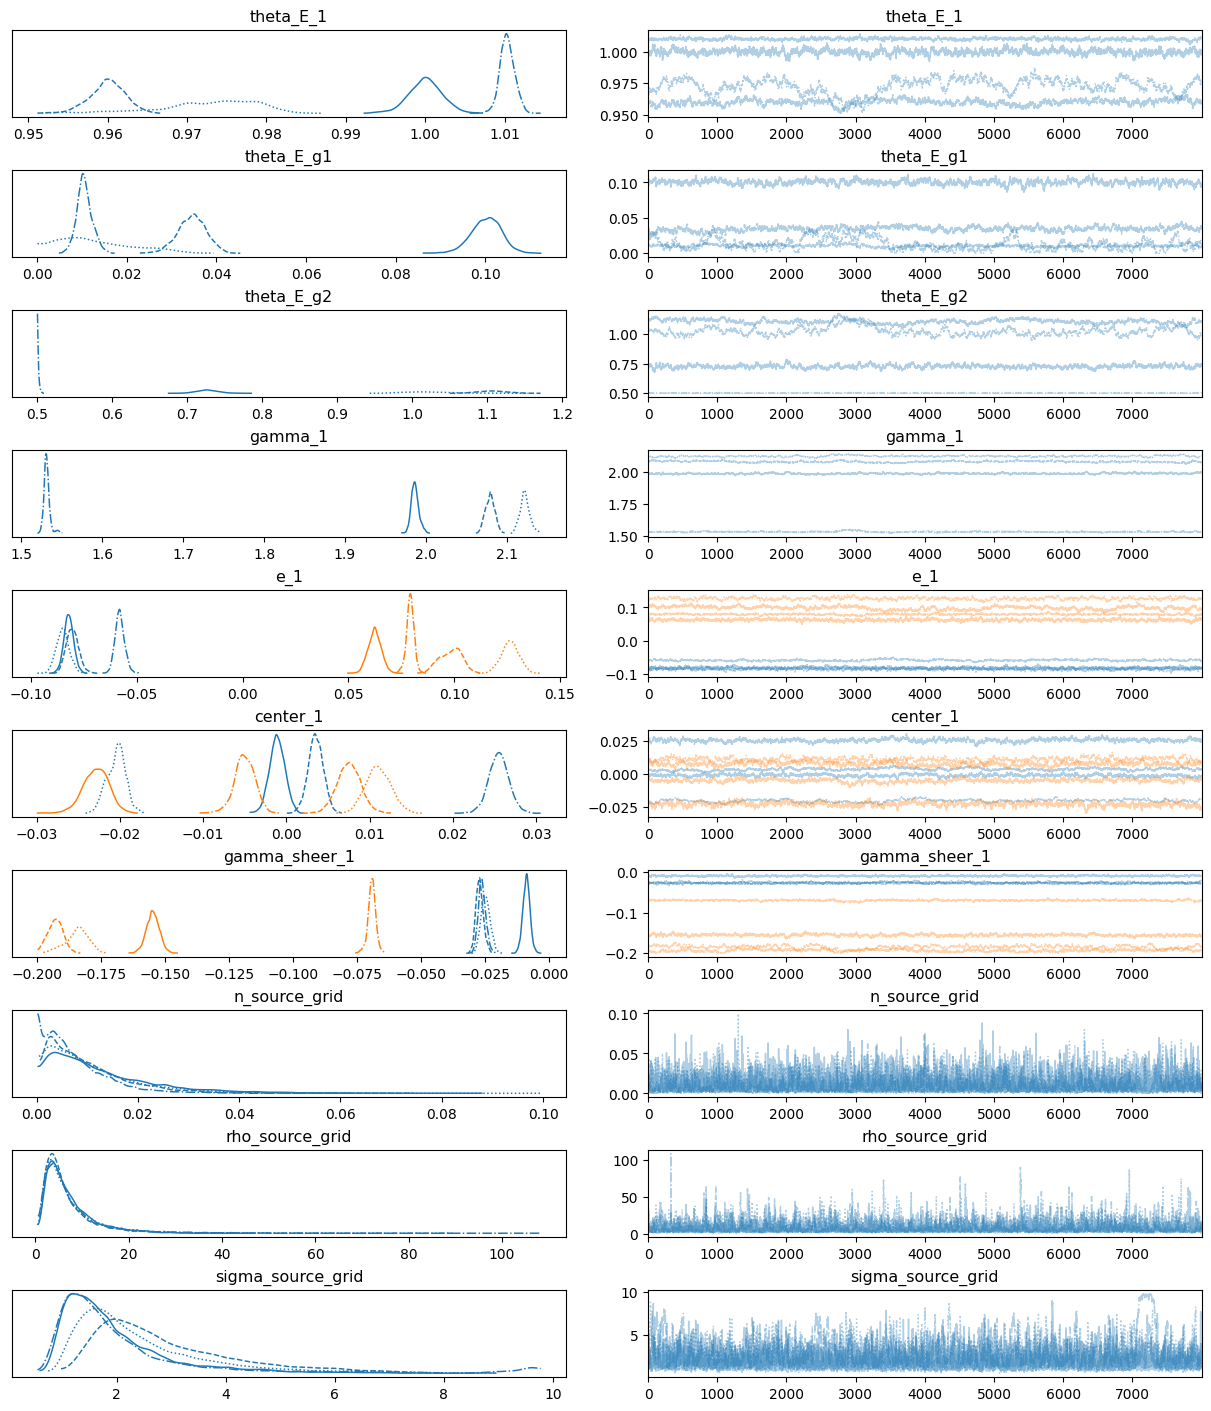

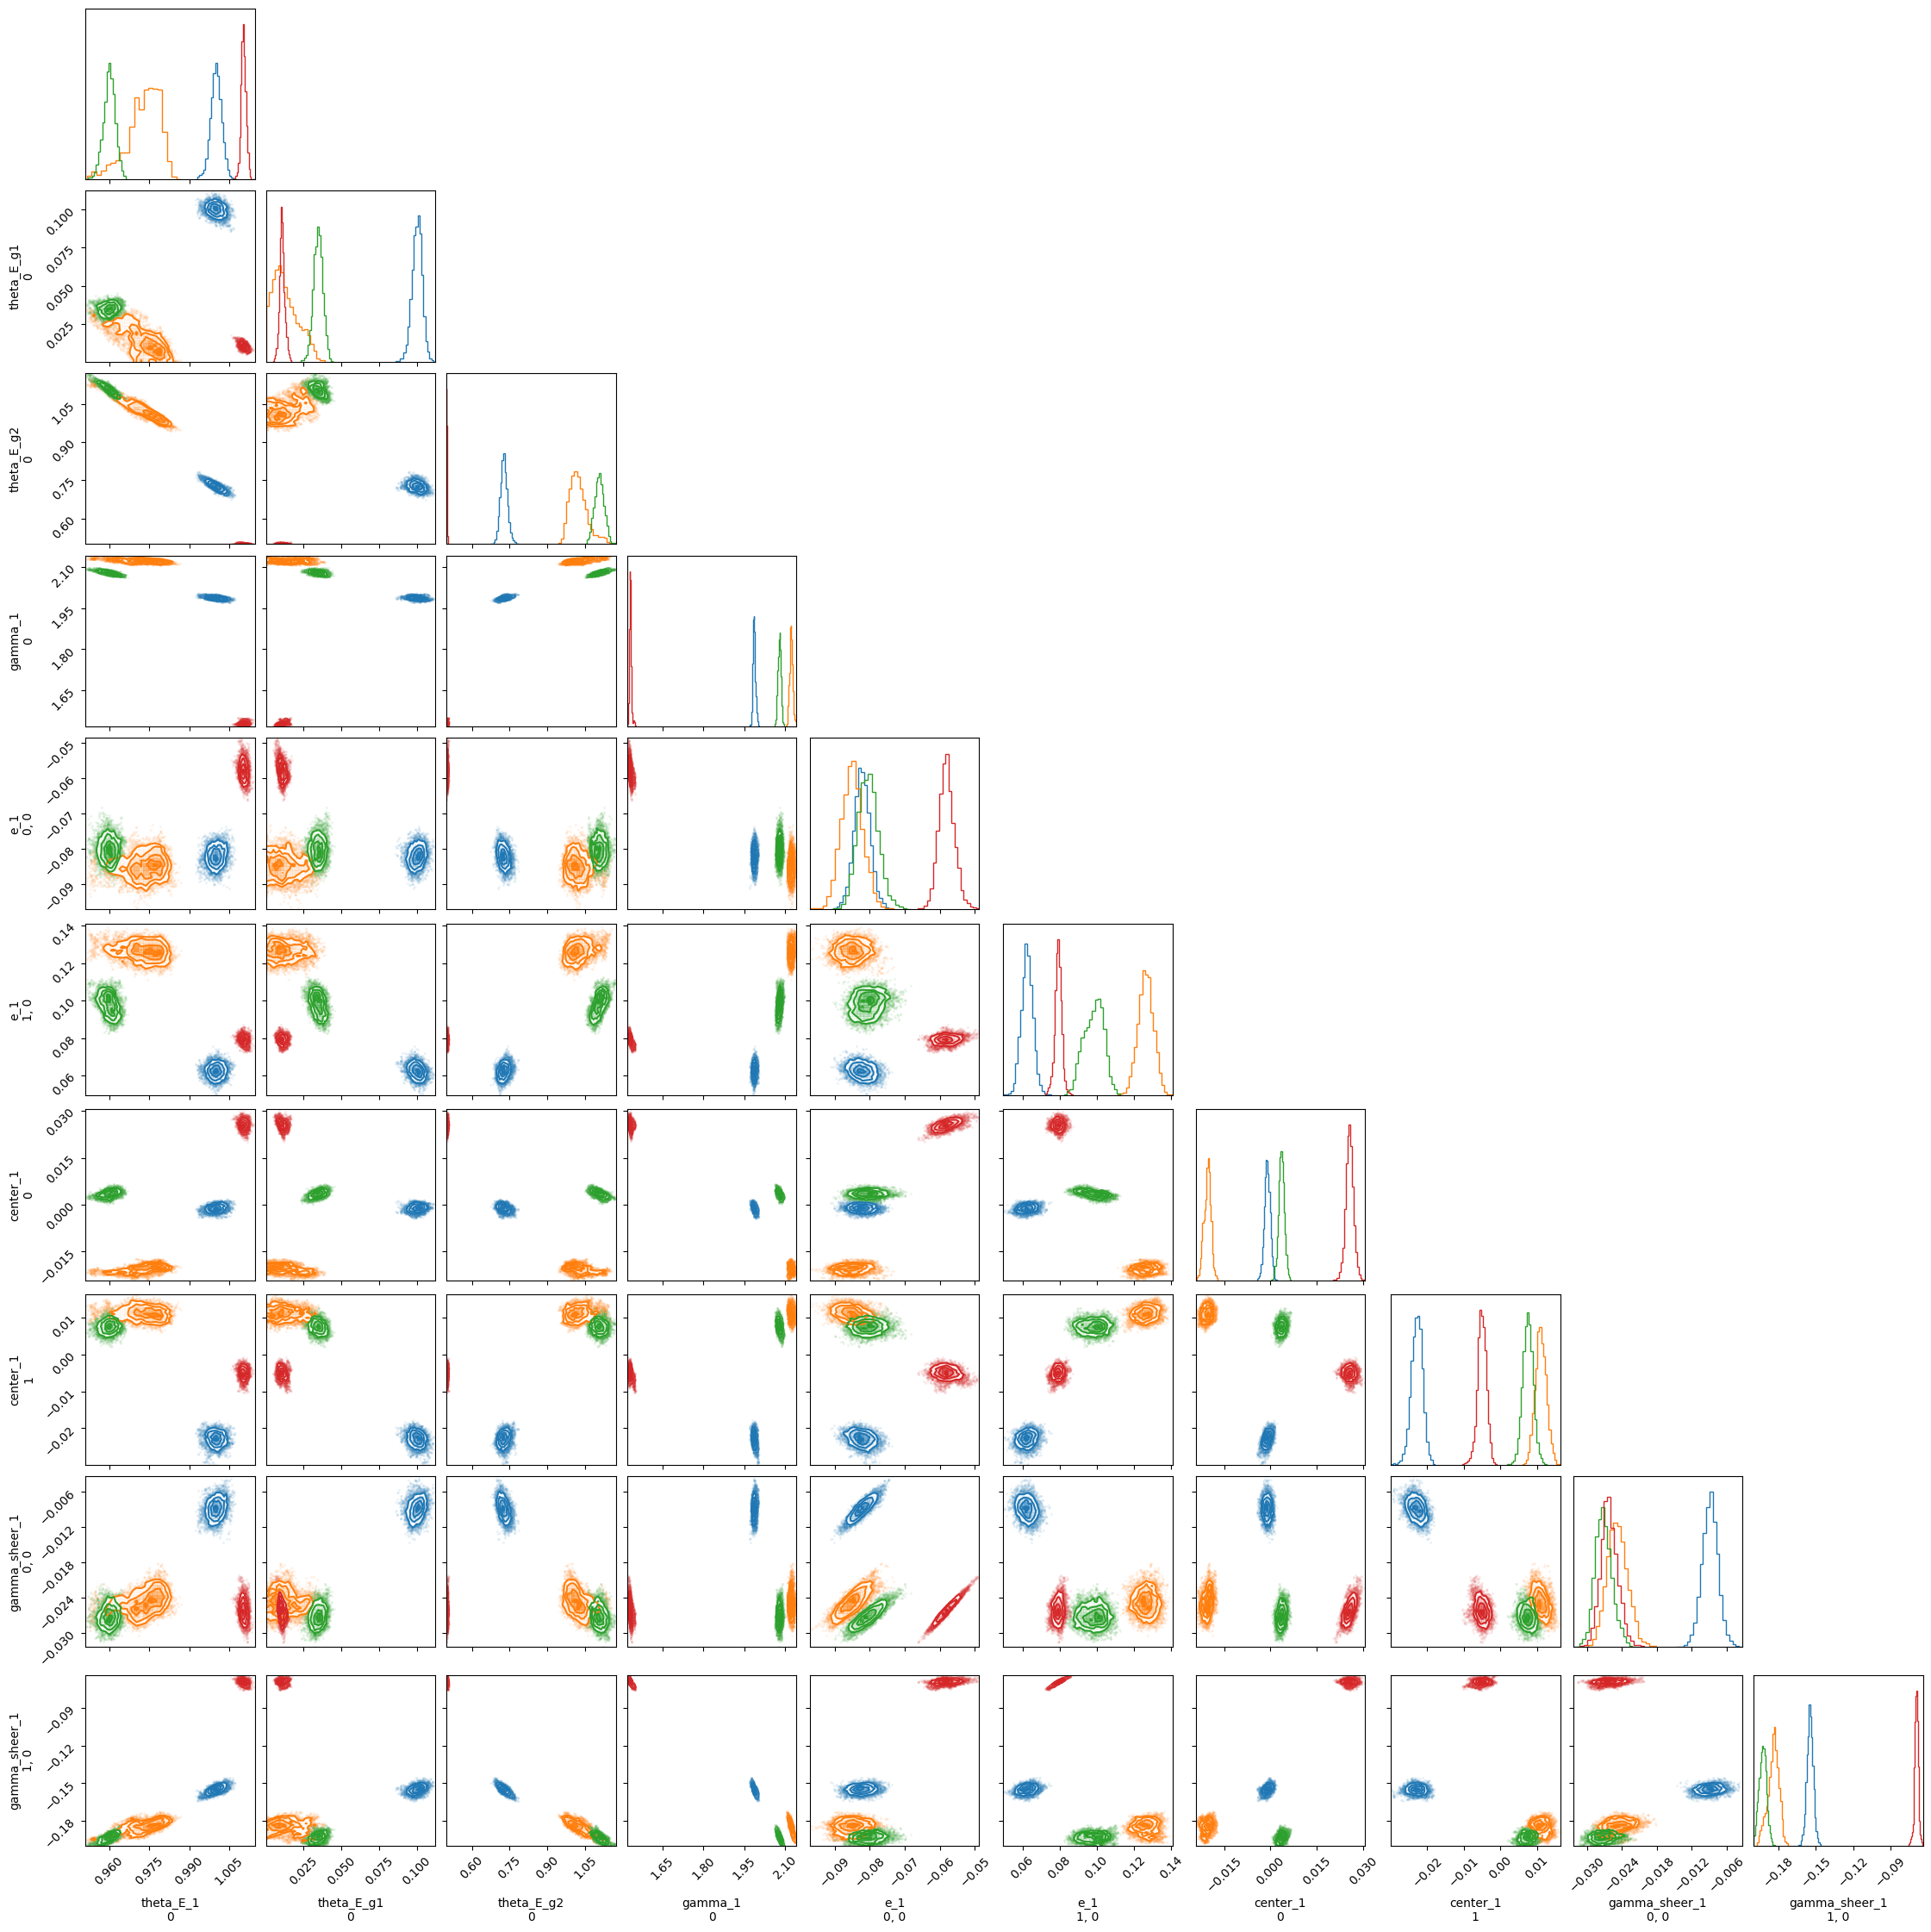

In [5]:
# Trace + corner diagnostics
vars_mass = ['theta_E_1', 'theta_E_g1', 'theta_E_g2', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']

plt.rcParams['figure.constrained_layout.use'] = True
_ = az.plot_trace(
    inf_data_pixel.sel(chain=np.arange(num_chains)),
    var_names=vars_mass + vars_power,
    figsize=(12, 14),
)
plt.show()

fig_corner = None
for i in range(num_chains):
    fig_corner = corner.corner(
        inf_data_pixel.posterior.isel(chain=i),
        var_names=vars_mass,
        color=f'C{i}',
        fig=fig_corner,
    )
plt.show()


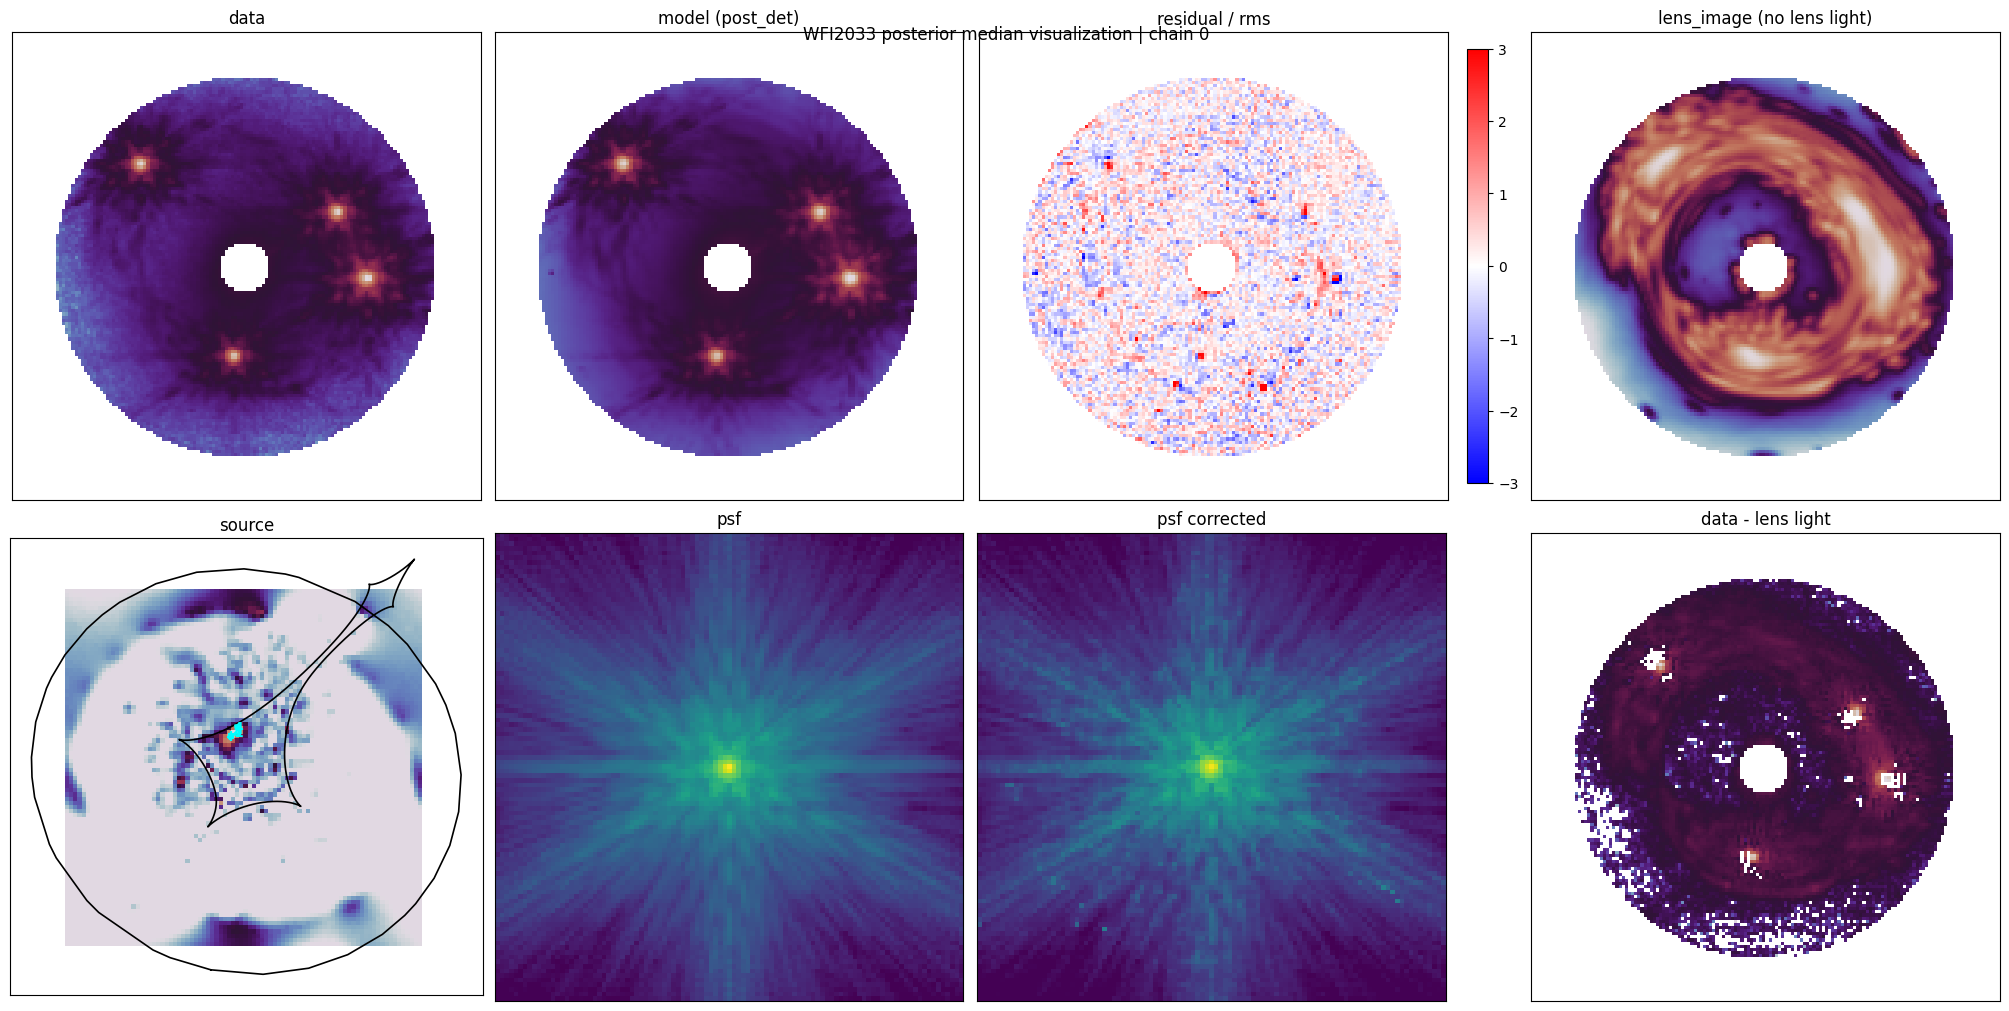

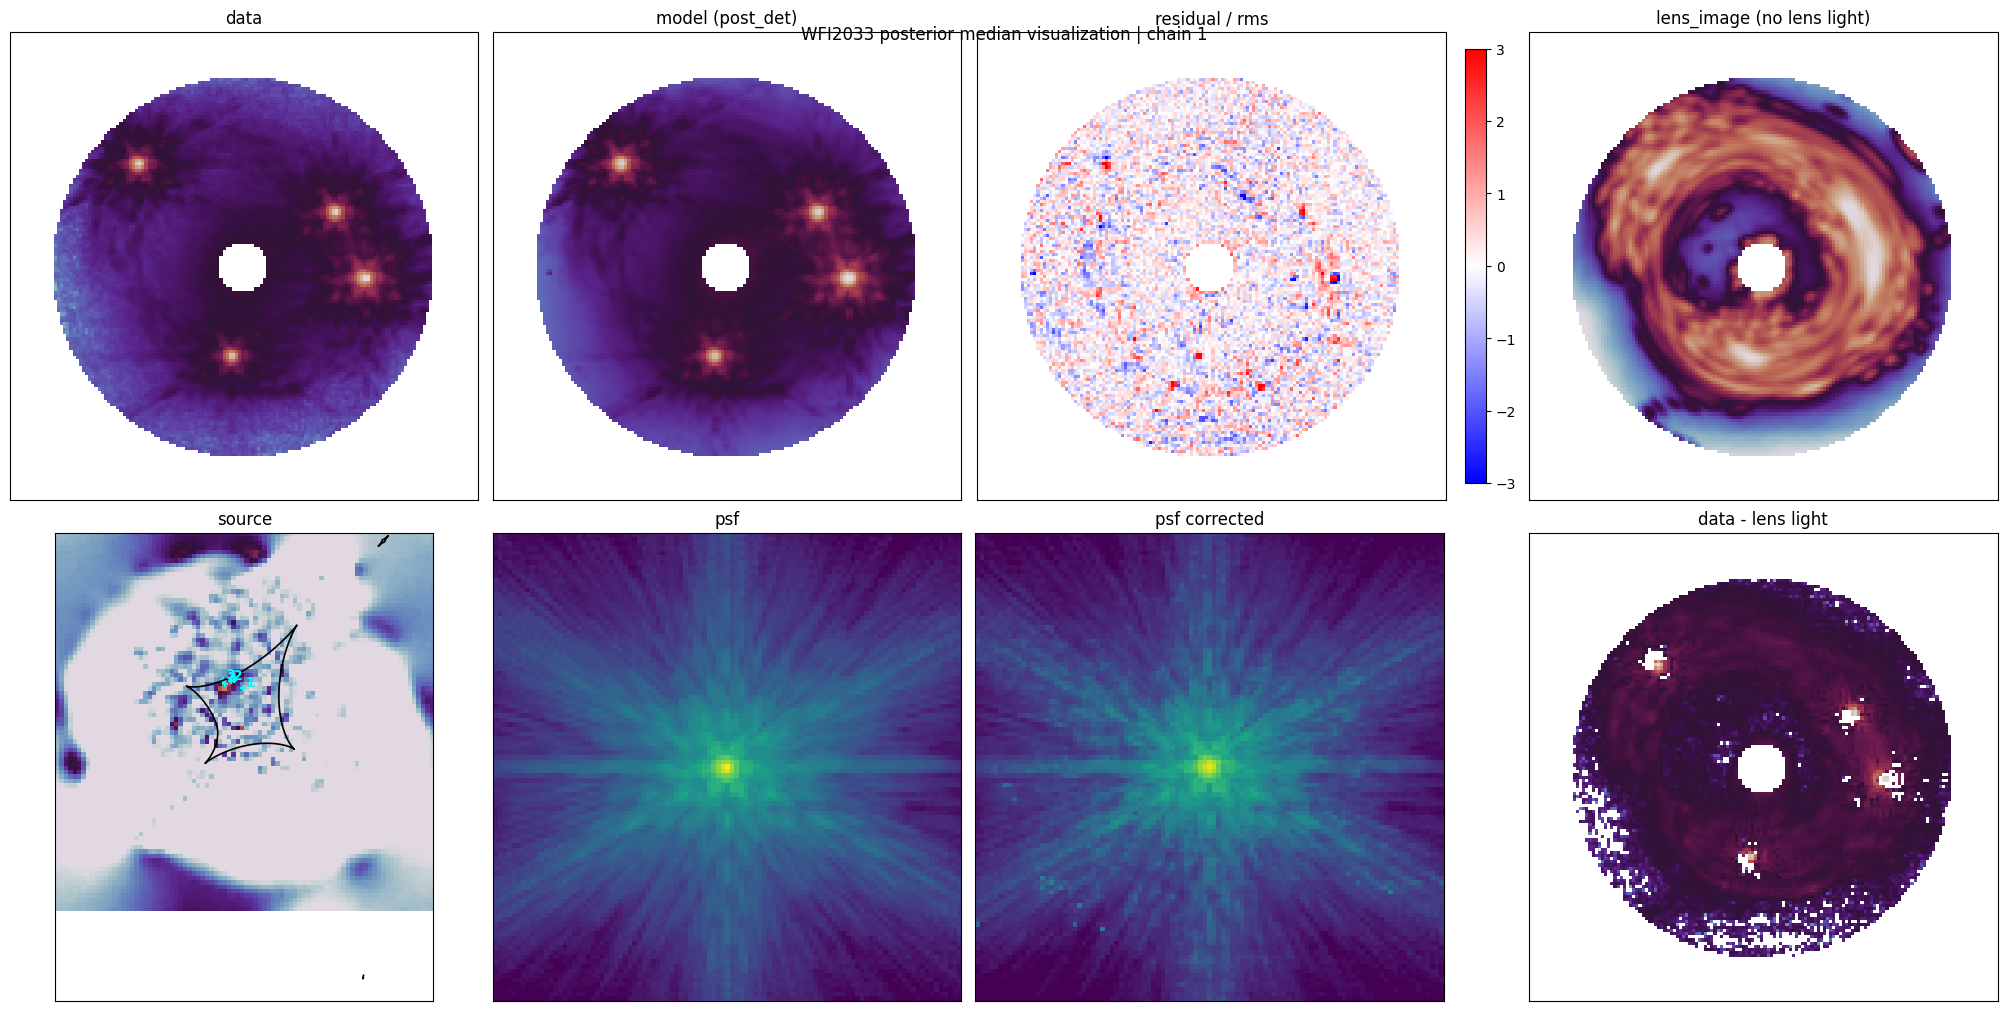

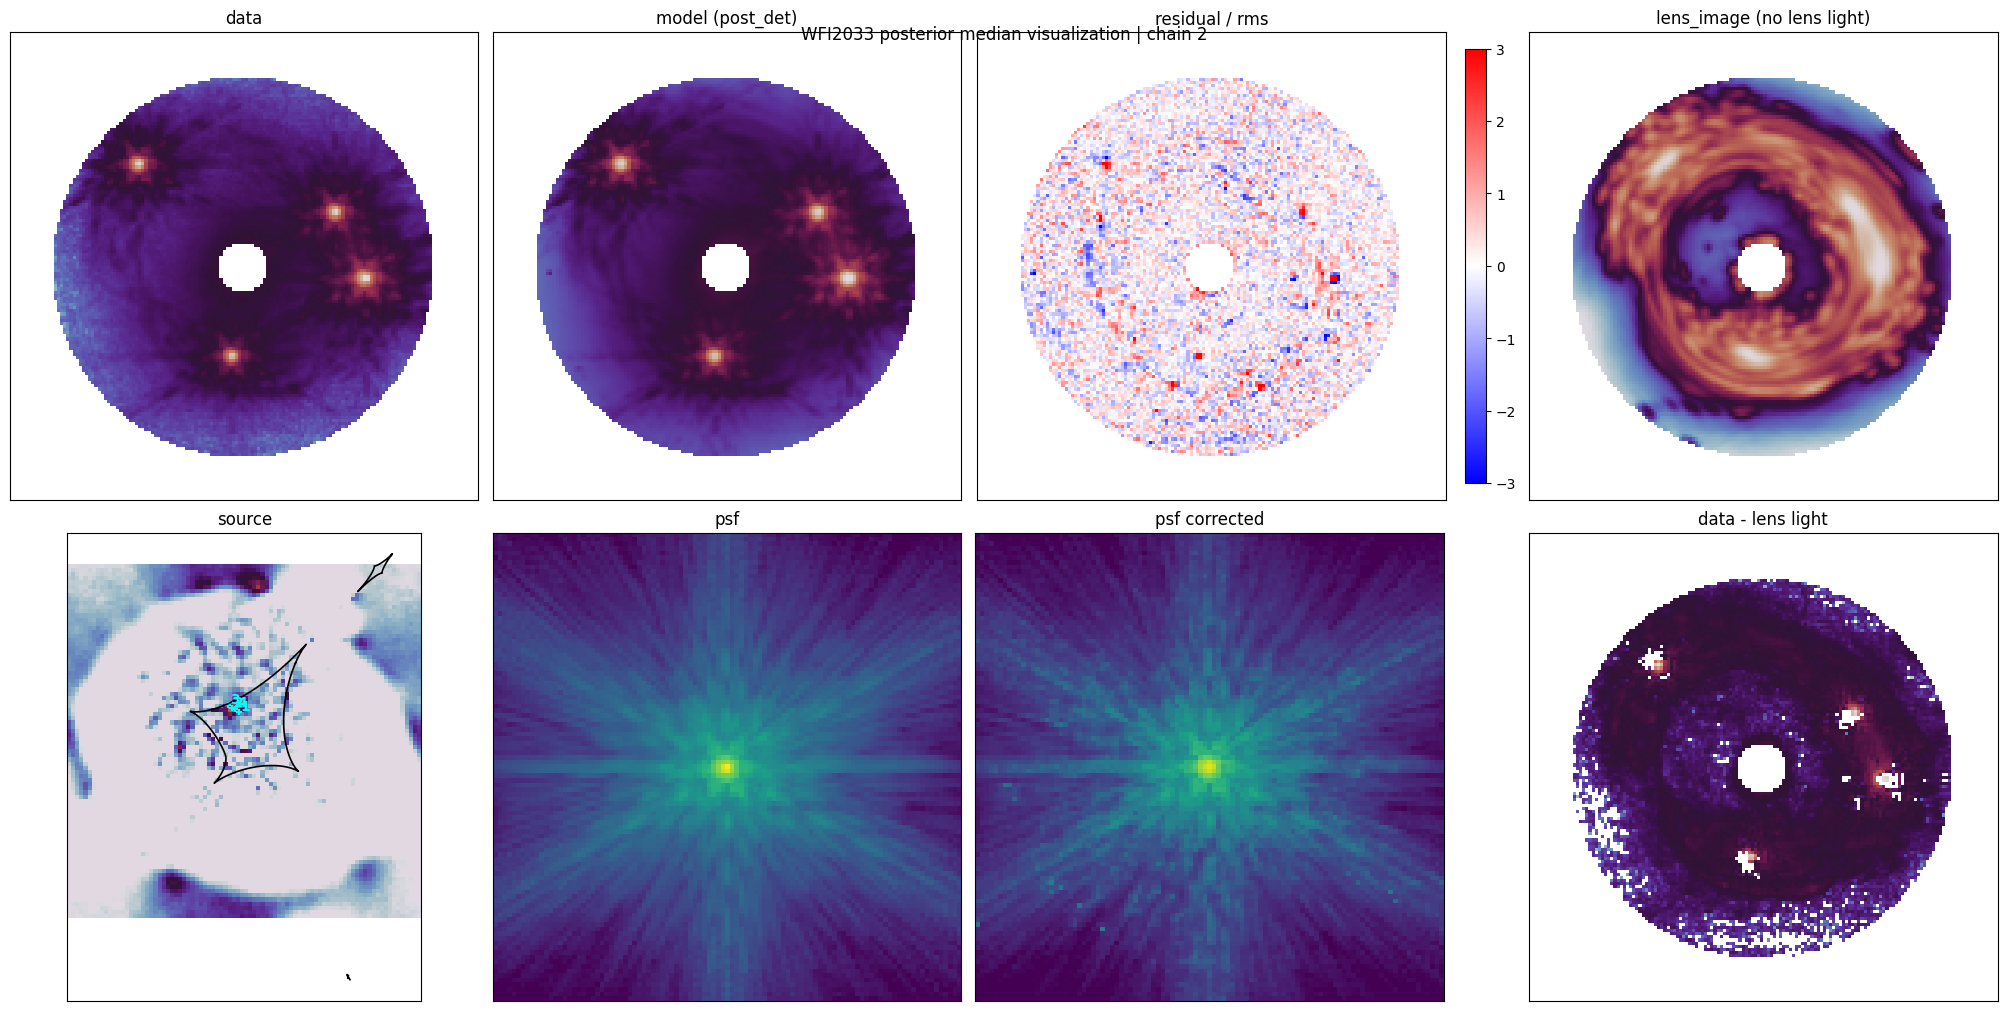

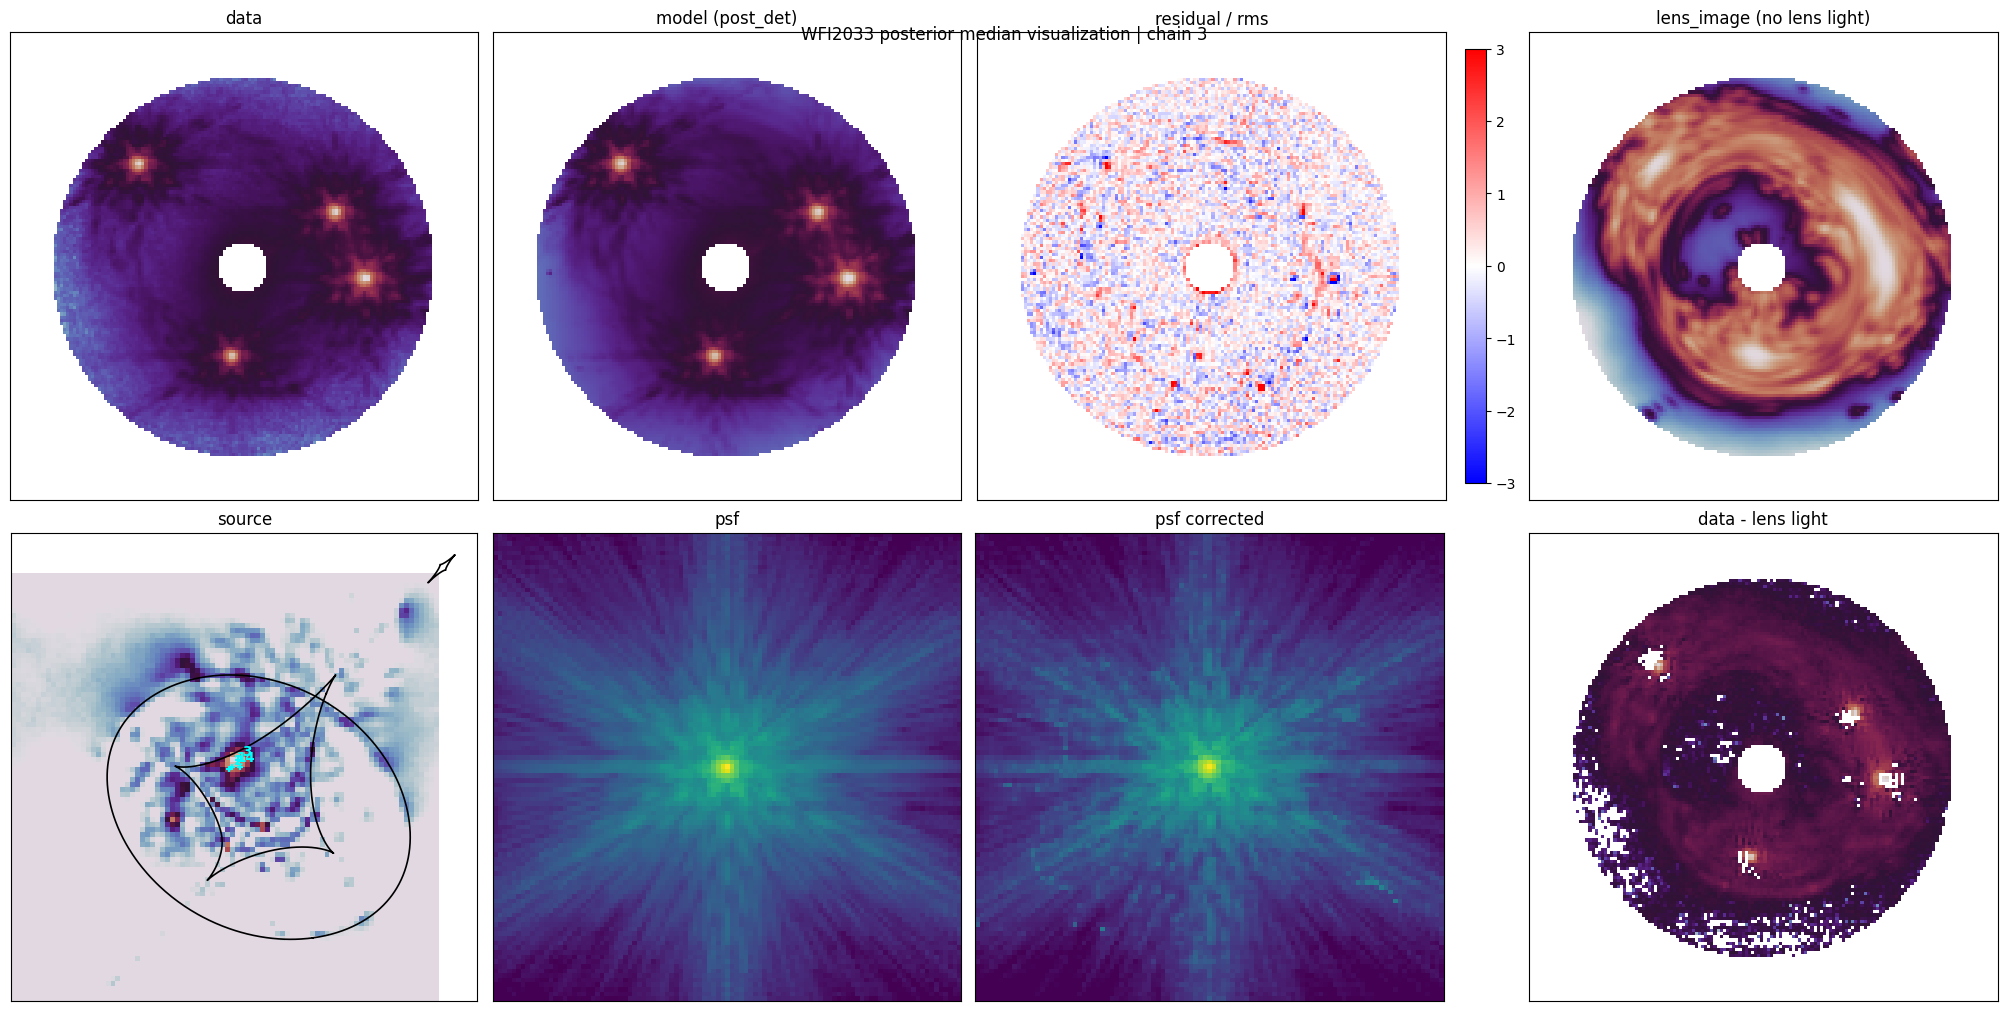

In [19]:
# Main visualization:
# row1: data | model(post_det) | residual | lens_image_pixel.model(without lens light)
# row2: source | psf | psf corrected | data - lens light
mask_plot = np.array(mask_out, dtype=bool)
rms_safe = np.array(rms_file, dtype=float)

for i in range(num_chains):
    kwargs_i = kwargs_chains[i]
    psf_corr_i = np.array(psf_corr_med[i], dtype=float)

    # Posterior deterministic model image
    model_det_i = np.array(model_image_med[i], dtype=float)
    residual_i = (data - model_det_i) / rms_safe

    # Full lens_image model without lens light (source + point source only)
    model_wo_lens_light_i = np.array(
        lens_image_pixel.model(
            **kwargs_i,
            source_add=True,
            lens_light_add=False,
            point_source_add=False,
            psf_kernel=psf_corr_i,
        )
    )

    # Lens-light-only model for data - lens_light panel
    lens_light_only_i = np.array(
        lens_image_pixel.model(
            **kwargs_i,
            source_add=False,
            lens_light_add=True,
            point_source_add=True,
            psf_kernel=psf_corr_i,
        )
    )

    source_i, source_extent = pixelize_plane_single(
        lens_image_pixel,
        kwargs_i,
        pixel_grid_shape,
    )
    src_x, src_y = trace_current_agn_to_source(lens_image_pixel, kwargs_i)
    src_x = np.array(src_x)
    src_y = np.array(src_y)

    critical_lines_i, caustics_i = model_util.critical_lines_caustics(
        lens_image_pixel,
        kwargs_i['kwargs_lens'],
        supersampling=10,
    )

    fig, ax = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'WFI2033 posterior median visualization | chain {i}', y=0.98)

    # row 1
    ax[0, 0].imshow(np.ma.array(data, mask=~mask_plot), norm='log', cmap='twilight', origin='lower', extent=extent, vmin = 0.001)
    ax[0, 0].set_title('data')

    ax[0, 1].imshow(np.ma.array(model_det_i, mask=~mask_plot), norm='log', cmap='twilight', origin='lower', extent=extent, vmin = 0.001)
    ax[0, 1].set_title('model (post_det)')

    im_res = ax[0, 2].imshow(np.ma.array(residual_i, mask=~mask_plot), cmap='bwr', vmin=-3, vmax=3, origin='lower', extent=extent)
    ax[0, 2].set_title('residual / rms')
    plt.colorbar(im_res, ax=ax[0, 2], fraction=0.046, pad=0.04)

    ax[0, 3].imshow(np.ma.array(model_wo_lens_light_i, mask=~mask_plot), norm='log', cmap='twilight', origin='lower', extent=extent)
    ax[0, 3].set_title('lens_image (no lens light)')

    # row 2
    src_abs = np.nanmax(np.abs(np.array(source_i)))
    src_norm = colors.SymLogNorm(
        linthresh=max(src_abs * 1e-3, 1e-8),
        vmin=-src_abs,
        vmax=src_abs,
    )
    ax[1, 0].imshow(np.array(source_i), cmap='twilight', origin='lower', extent=source_extent)
    for curve_x, curve_y in caustics_i:
        ax[1, 0].plot(curve_x, curve_y, color='black', linewidth=1.2)
    ax[1, 0].scatter(src_x, src_y, s=15, facecolors='cyan', marker='+', linewidths=1.6)
    for j, (sx, sy) in enumerate(zip(src_x, src_y), start=1):
        ax[1, 0].text(sx + 0.01, sy + 0.01, str(j), color='cyan', fontsize=10, weight='bold')
    ax[1, 0].set_title('source')

    eps = 1e-12
    vmax_psf = np.nanmax([np.nanmax(psf_base), np.nanmax(psf_corr_i)])
    psf_norm = colors.LogNorm(vmin=max(vmax_psf * 1e-6, eps), vmax=max(vmax_psf, eps * 10))

    ax[1, 1].imshow(np.clip(psf_base, eps, None), cmap='viridis', norm=psf_norm, origin='lower')
    ax[1, 1].set_title('psf')

    ax[1, 2].imshow(np.clip(psf_corr_i, eps, None), cmap='viridis', norm=psf_norm, origin='lower')
    ax[1, 2].set_title('psf corrected')

    ax[1, 3].imshow(np.ma.array(data - lens_light_only_i, mask=~mask_plot), norm='log', cmap='twilight', origin='lower', extent=extent)
    ax[1, 3].set_title('data - lens light')

    for a in ax.ravel():
        a.set_xticks([])
        a.set_yticks([])

    plt.show()
